# Regular Expressions Are Finite Automata — An Engine From Scratch

`import re` hides three facts worth seeing in full:

1. a regex **is** a finite-state machine — accept (1) or reject (0), nothing more;
2. **capture groups** are not part of that machine — they need a separate backtracking pass;
3. the instant a pattern must **count** (balanced parentheses), it has left the regular languages
   and needs a **stack**.

This notebook drives the repo's `regex_engine.py`: pattern → AST → **Thompson NFA** → **subset-
construction DFA** → captures, validated exhaustively against Python's `re`. Continues the FSM/regex
thread (`_repl_sql_fsm_chem_oddlang.py`, `gas_laser_regex_verilog_cuda.ipynb`).

In [1]:
import sys, pathlib, re
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import regex_engine as rx

print("regex_engine loaded")

regex_engine loaded


## §1 Pattern → AST

A regex is a little language; parsing it is recursive descent with the precedence
**alternation `|` < concatenation < repetition `* + ?` < atom**. Grouping `()` both overrides
precedence and (later) marks a capture.

In [2]:
from pprint import pformat
for pat in ["abc", "a|b", "ab*c", "(a|b)*abb", "a(bc)+d?"]:
    print(f"{pat!r:14} -> {pformat(rx.parse(pat), width=100)}")

# malformed patterns are rejected with a clear message (input validation)
for bad in ["(a", "a)", "*a", "a\\"]:
    try:
        rx.parse(bad)
    except ValueError as e:
        print(f"reject {bad!r:6}: {e}")

'abc'          -> ('concat', ('concat', ('char', 'a'), ('char', 'b')), ('char', 'c'))
'a|b'          -> ('alt', ('char', 'a'), ('char', 'b'))
'ab*c'         -> ('concat', ('concat', ('char', 'a'), ('star', ('char', 'b'))), ('char', 'c'))
'(a|b)*abb'    -> ('concat',
 ('concat',
  ('concat', ('star', ('group', ('alt', ('char', 'a'), ('char', 'b')), 1)), ('char', 'a')),
  ('char', 'b')),
 ('char', 'b'))
'a(bc)+d?'     -> ('concat',
 ('concat', ('char', 'a'), ('plus', ('group', ('concat', ('char', 'b'), ('char', 'c')), 1))),
 ('opt', ('char', 'd')))
reject '(a'  : unbalanced '(' : missing ')'
reject 'a)'  : unexpected ')' at position 1
reject '*a'  : dangling quantifier '*' at position 0
reject 'a\\' : trailing backslash with nothing to escape


## §2 AST → NFA (Thompson construction)

Each operator becomes a tiny gadget wired with $\varepsilon$ (empty) moves: concatenation joins
end-to-start, alternation forks and rejoins, the star adds a skip edge and a loop edge. The result
has at most $2\times(\text{pattern length})$ states and **no backtracking** — its branching lives
in being in many states at once.

In [3]:
nfa = rx.to_nfa(rx.parse("(a|b)*abb"))
print(f"NFA for (a|b)*abb : {nfa.n_states} states, start={nfa.start}, accept={nfa.accept}\n")
SYM = {None: "eps"}
def symname(s):
    return "eps" if s is None else (s[1] if s[0] == "char" else ".")
for state in sorted(nfa.trans):
    edges = ", ".join(f"--{symname(sym)}-->{to}" for sym, to in nfa.trans[state])
    print(f"  q{state}: {edges if edges else '(no out-edges)'}")

NFA for (a|b)*abb : 14 states, start=0, accept=13

  q0: --eps-->2, --eps-->1
  q1: --eps-->8
  q2: --eps-->4, --eps-->6
  q3: --eps-->2, --eps-->1
  q4: --a-->5
  q5: --eps-->3
  q6: --b-->7
  q7: --eps-->3
  q8: --a-->9
  q9: --eps-->10
  q10: --b-->11
  q11: --eps-->12
  q12: --b-->13
  q13: (no out-edges)


## §3 Matching by NFA simulation — the no-backtracking matcher

Track the **set** of states reachable so far; on each input symbol, step every state forward and
take the $\varepsilon$-closure. Linear time in the input, immune to the catastrophic backtracking
that pathological patterns inflict on naive engines.

In [4]:
r = rx.Regex("(a|b)*abb")
tests = ["abb", "aabb", "babb", "ab", "abba", "bbbabb", ""]
for s in tests:
    print(f"  (a|b)*abb  ~  {s!r:8}: NFA={r.fullmatch(s)}   "
          f"re={re.fullmatch('(a|b)*abb', s) is not None}")

  (a|b)*abb  ~  'abb'   : NFA=True   re=True
  (a|b)*abb  ~  'aabb'  : NFA=True   re=True
  (a|b)*abb  ~  'babb'  : NFA=True   re=True
  (a|b)*abb  ~  'ab'    : NFA=False   re=False
  (a|b)*abb  ~  'abba'  : NFA=False   re=False
  (a|b)*abb  ~  'bbbabb': NFA=True   re=True
  (a|b)*abb  ~  ''      : NFA=False   re=False


## §4 NFA → DFA (subset construction)

Determinise: each DFA state is the *set* of NFA states the machine could be in. One transition per
(state, symbol), so matching is a bare table walk — exactly the FSM you would burn into hardware or
a lexer. Below: the DFA for `(a|b)*abb` over the alphabet $\{a,b\}$, with its state diagram.

In [5]:
start, trans, accept = rx.to_dfa(nfa, "ab")
# name the frozenset states D0, D1, ... in discovery order
order = [start] + [S for S in trans if S != start]
name = {S: f"D{i}" for i, S in enumerate(order)}
print("DFA transition table ( * = accepting ):\n")
print(f"  {'state':6} {'on a':6} {'on b':6}  NFA-subset")
for S in order:
    mark = "*" if S in accept else " "
    print(f" {mark}{name[S]:6}{name[trans[S]['a']]:6}{name[trans[S]['b']]:6}  "
          f"{{{','.join('q'+str(q) for q in sorted(S))}}}")

DFA transition table ( * = accepting ):

  state  on a   on b    NFA-subset
  D0    D2    D1      {q0,q1,q2,q4,q6,q8}
  D1    D2    D1      {q1,q2,q3,q4,q6,q7,q8}
  D2    D2    D3      {q1,q2,q3,q4,q5,q6,q8,q9,q10}
  D3    D2    D4      {q1,q2,q3,q4,q6,q7,q8,q11,q12}
 *D4    D2    D1      {q1,q2,q3,q4,q6,q7,q8,q13}


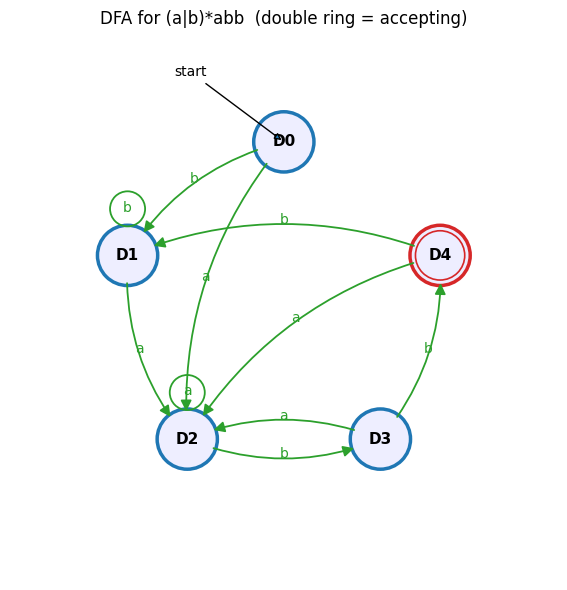

In [6]:
# draw the DFA state diagram
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle

n = len(order)
ang = np.linspace(0.5*np.pi, 0.5*np.pi + 2*np.pi, n, endpoint=False)
pos = {order[i]: (3*np.cos(ang[i]), 3*np.sin(ang[i])) for i in range(n)}

fig, ax = plt.subplots(figsize=(7.5, 6))
for S in order:
    x, y = pos[S]
    ax.add_patch(Circle((x, y), 0.55, fill=True, fc="#eef",
                        ec="C3" if S in accept else "C0", lw=2.5))
    if S in accept:
        ax.add_patch(Circle((x, y), 0.45, fill=False, ec="C3", lw=1.2))
    ax.text(x, y, name[S], ha="center", va="center", fontsize=11, weight="bold")

drawn = {}
for S in order:
    for ch in "ab":
        T = trans[S][ch]
        if T not in pos:
            continue
        key = (S, T)
        rad = 0.25 if (T, S) in drawn or S == T else 0.0
        drawn[key] = drawn.get(key, "") + ch
for (S, T), label in drawn.items():
    x1, y1 = pos[S]; x2, y2 = pos[T]
    if S == T:
        ax.annotate(label, (x1, y1+0.8), ha="center", fontsize=10, color="C2")
        ax.add_patch(Circle((x1, y1+0.85), 0.32, fill=False, ec="C2", lw=1.3))
    else:
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
                     connectionstyle=f"arc3,rad={0.2}", arrowstyle="-|>",
                     mutation_scale=16, lw=1.3, color="C2",
                     shrinkA=20, shrinkB=20))
        mx, my = (x1+x2)/2 + 0.3*(y2-y1)/3, (y1+y2)/2 - 0.3*(x2-x1)/3
        ax.text(mx, my, label, ha="center", fontsize=10, color="C2")
ax.annotate("start", pos[start], (pos[start][0]-2, pos[start][1]+1.2),
            arrowprops=dict(arrowstyle="-|>"), fontsize=10)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("DFA for (a|b)*abb  (double ring = accepting)")
plt.tight_layout(); plt.show()

## §5 Proof by exhaustion: NFA ≡ DFA ≡ Python `re`

The strongest test for an engine: enumerate **every** string up to some length and confirm all
matchers agree with the reference implementation. Below, 0 disagreements across thousands of cases.

In [7]:
import itertools
def all_strings(alphabet, max_len):
    for k in range(max_len + 1):
        for t in itertools.product(alphabet, repeat=k):
            yield "".join(t)

patterns = ["a*", "(a|b)*", "(ab)*", "a+b", "a?b", "(a|b)*abb",
            ".*", "a.b", "(aa|bb)*", "a(b|a)*b"]
strings = list(all_strings("ab", 7))
total, mismatches = 0, 0
for pat in patterns:
    comp = rx.Regex(pat, alphabet="ab")
    pyre = re.compile(pat)
    for s in strings:
        ref = pyre.fullmatch(s) is not None
        if not (ref == comp.fullmatch(s) == comp.fullmatch_dfa(s)
                == (rx.fullmatch_groups(pat, s) is not None)):
            mismatches += 1
        total += 1
print(f"{len(patterns)} patterns x {len(strings)} strings = {total} checks")
print(f"disagreements among re / NFA / DFA / backtracking: {mismatches}")

10 patterns x 255 strings = 2550 checks
disagreements among re / NFA / DFA / backtracking: 0


## §6 Capture groups ("caps") need backtracking

Whether `abab` split as `(ab)*` came through group 1 as `ab` is information the *accept/reject*
machine throws away. To recover spans you must **backtrack** through the AST, recording where each
group opened and closed — a separate matcher, and the one vulnerable to exponential blowup that the
NFA simulation in §3 sidesteps.

In [8]:
for pat, s in [("(a)(b)", "ab"), ("(ab)*", "abab"),
               ("(a*)(b*)", "aaabb"), ("a(.)c", "axc"), ("(a|b)(a|b)", "ba")]:
    mine = rx.fullmatch_groups(pat, s)
    ref = re.fullmatch(pat, s)
    ref_g = {i: ref.group(i) for i in range(ref.re.groups + 1)}
    print(f"  {pat!r:12} on {s!r:7}: {mine}   (re: {ref_g})")

  '(a)(b)'     on 'ab'   : {0: 'ab', 1: 'a', 2: 'b'}   (re: {0: 'ab', 1: 'a', 2: 'b'})
  '(ab)*'      on 'abab' : {0: 'abab', 1: 'ab'}   (re: {0: 'abab', 1: 'ab'})
  '(a*)(b*)'   on 'aaabb': {0: 'aaabb', 1: 'aaa', 2: 'bb'}   (re: {0: 'aaabb', 1: 'aaa', 2: 'bb'})
  'a(.)c'      on 'axc'  : {0: 'axc', 1: 'x'}   (re: {0: 'axc', 1: 'x'})
  '(a|b)(a|b)' on 'ba'   : {0: 'ba', 1: 'b', 2: 'a'}   (re: {0: 'ba', 1: 'b', 2: 'a'})


## §7 `1:0`, and the wall: `stack = []`

A DFA is *finite* state — it cannot count to arbitrary depth, so **no regex matches balanced
parentheses** $\{\,(^n\,)^n\,\}$. The proof is the **pumping lemma**: any DFA with $p$ states fed
$(^p\,)^p$ must repeat a state inside the opening run, and pumping that loop adds opens without
closes — an accepted string that is no longer balanced. The cure is one data structure: a **stack**
(a pushdown automaton), which lifts you from *regular* to *context-free*.

In [9]:
# a regex literally cannot enforce equal counts:
naive = rx.Regex(r"\(*\)*", alphabet="()")
print(r"regex \(*\)* accepts '(()':", naive.fullmatch("(()"), " <- WRONG (can't count)")
print()
# the stack-based recognizer (pushdown automaton) gets it right:
print("stack-based balanced-parens recognizer:")
for s in ["()", "(())", "(()())", "((()))", "(", ")(", "(()", "())("]:
    print(f"  {s!r:9} -> {rx.balanced_parentheses(s)}")

regex \(*\)* accepts '(()': True  <- WRONG (can't count)

stack-based balanced-parens recognizer:
  '()'      -> True
  '(())'    -> True
  '(()())'  -> True
  '((()))'  -> True
  '('       -> False
  ')('      -> False
  '(()'     -> False
  '())('    -> False


In [ ]:
# the pumping lemma made concrete: a DFA built for depth <= K fails at K+1.
def depthK_regex(K):
    # matches ( ^n ) ^n only for n <= K -- a finite unrolling, NOT all n
    alts = ["".join(["("]*n + [")"]*n) for n in range(K + 1)]
    # build (|...|...) as an alternation of literal balanced strings
    esc = lambda t: t.replace("(", r"\(").replace(")", r"\)")
    return "(" + "|".join(esc(a) if a else "" for a in alts) + ")"

K = 4
rgx = rx.Regex(depthK_regex(K), alphabet="()")
print(f"finite DFA tuned for depth <= {K}:")
for n in range(K + 3):
    s = "("*n + ")"*n
    inside = rgx.fullmatch(s)
    print(f"  n={n}: ( ^{n} ) ^{n}  regex={inside}   stack={rx.balanced_parentheses(s)}"
          f"{'   <- DFA breaks here' if (not inside) and n > K else ''}")

finite DFA tuned for depth <= 4:
  n=0: ( ^0 ) ^0  regex=True   stack=True
  n=1: ( ^1 ) ^1  regex=True   stack=True
  n=2: ( ^2 ) ^2  regex=True   stack=True
  n=3: ( ^3 ) ^3  regex=True   stack=True
  n=4: ( ^4 ) ^4  regex=True   stack=True
  n=5: ( ^5 ) ^5  regex=False   stack=True   <- DFA breaks here
  n=6: ( ^6 ) ^6  regex=False   stack=True   <- DFA breaks here


: 

## §8 Where this lands

- **Lexers / tokenizers**: every compiler front end (and the Verilog/SQL tokenizing in
  `gas_laser_regex_verilog_cuda.ipynb` and `_repl_sql_fsm_chem_oddlang.py`) is exactly §4's DFA
  table walk — regex compiled to a state machine, run at one transition per character.
- **Hardware FSMs**: the DFA *is* a Moore machine; the state diagram in §4 is a circuit. Protocol
  decoders and the rogue-wave trigger logic in `gs_monitor.py` are the same accept/reject automaton.
- **Bioinformatics**: motif search over DNA is regex over the alphabet $\{A,C,G,T\}$; the NFA
  simulation is the basis of fast scanners.
- **The Chomsky ladder**: regular ⊂ context-free ⊂ context-sensitive ⊂ recursively-enumerable. §7
  is the first rung — `stack=[]` buys parentheses (CFGs, parsers); a full tape buys a Turing
  machine. Knowing which rung a problem sits on tells you the cheapest machine that can solve it.